In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =============================================
# (a) Load and Explore the Dataset
# =============================================
df = pd.read_csv('customer_subscription_churn_usage_patterns.csv')

print("=== (a) First five records ===")
print(df.head())

print("\nDataset size (rows, columns):", df.shape)
print("\nData types:\n", df.dtypes)
print("\nChurn distribution:\n", df['churn'].value_counts(normalize=True)*100, "%")

=== (a) First five records ===
   user_id signup_date plan_type  monthly_fee  avg_weekly_usage_hours  \
0        1  2023-04-15   Premium          699                     1.1   
1        2  2023-08-27   Premium          699                     2.6   
2        3  2023-10-12   Premium          699                    14.3   
3        4  2023-12-11     Basic          199                    17.6   
4        5  2023-02-14     Basic          199                     9.8   

   support_tickets  payment_failures  tenure_months  last_login_days_ago churn  
0                4                 1              8                   14   Yes  
1                6                 0             35                    1   Yes  
2                8                 3              2                   14   Yes  
3                5                 2             11                    9   Yes  
4                5                 2              6                   38   Yes  

Dataset size (rows, columns): (2800, 10)

D

In [3]:
# =============================================
# (b) Data Cleaning and Preprocessing
# =============================================
print("Missing values:\n", df.isnull().sum())   # Should be 0

# Drop useless columns
df = df.drop(['user_id', 'signup_date'], axis=1)

# Encode categorical variables
le_plan = LabelEncoder()
df['plan_type_encoded'] = le_plan.fit_transform(df['plan_type'])

le_churn = LabelEncoder()
df['churn_encoded'] = le_churn.fit_transform(df['churn'])   # Yes=1, No=0

# Scale numerical features
num_cols = ['monthly_fee', 'avg_weekly_usage_hours', 'support_tickets',
            'payment_failures', 'tenure_months', 'last_login_days_ago']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("\nAfter preprocessing (first 5 rows):")
print(df.head())
print("\nEncoding example - Plan types:", dict(zip(le_plan.classes_, range(len(le_plan.classes_)))))

Missing values:
 user_id                   0
signup_date               0
plan_type                 0
monthly_fee               0
avg_weekly_usage_hours    0
support_tickets           0
payment_failures          0
tenure_months             0
last_login_days_ago       0
churn                     0
dtype: int64

After preprocessing (first 5 rows):
  plan_type  monthly_fee  avg_weekly_usage_hours  support_tickets  \
0   Premium     1.287607               -1.658797         0.043033   
1   Premium     1.287607               -1.447780         0.810507   
2   Premium     1.287607                0.198155         1.577980   
3     Basic    -1.143806                0.662393         0.426770   
4     Basic    -1.143806               -0.434897         0.426770   

   payment_failures  tenure_months  last_login_days_ago churn  \
0         -0.882012      -1.023159            -0.896660   Yes   
1         -1.473257       1.579844            -1.624969   Yes   
2          0.300479      -1.601604         

=== Correlation Matrix (rounded) ===
                        monthly_fee  avg_weekly_usage_hours  support_tickets  \
monthly_fee                   1.000                  -0.030            0.015   
avg_weekly_usage_hours       -0.030                   1.000            0.031   
support_tickets               0.015                   0.031            1.000   
payment_failures             -0.018                   0.014           -0.007   
tenure_months                 0.015                  -0.010           -0.045   
last_login_days_ago          -0.003                  -0.002           -0.059   
plan_type_encoded             0.393                  -0.015            0.019   
churn_encoded                 0.004                  -0.104            0.150   

                        payment_failures  tenure_months  last_login_days_ago  \
monthly_fee                       -0.018          0.015               -0.003   
avg_weekly_usage_hours             0.014         -0.010               -0.002   
su

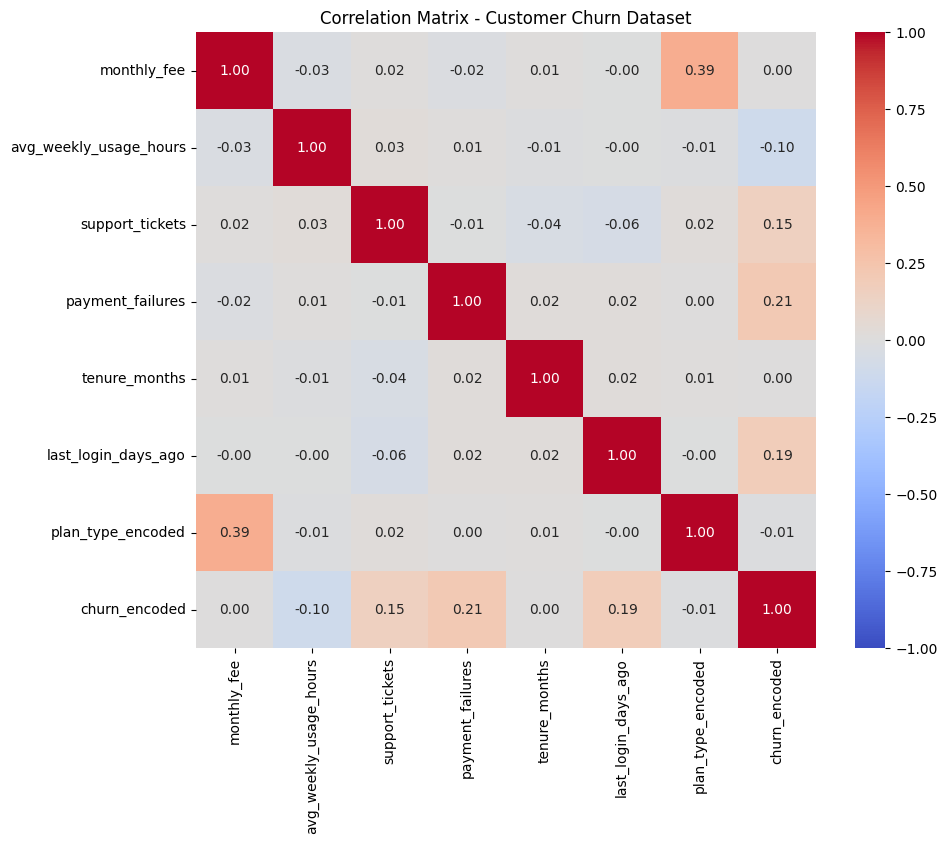


Features most related to churn (churn_encoded):
churn_encoded             1.000000
payment_failures          0.213752
last_login_days_ago       0.186366
support_tickets           0.149623
monthly_fee               0.003796
tenure_months             0.002044
plan_type_encoded        -0.014840
avg_weekly_usage_hours   -0.103788
Name: churn_encoded, dtype: float64


In [4]:
# =============================================
# (c) Show the Correlation Matrix
# =============================================
corr_cols = num_cols + ['plan_type_encoded', 'churn_encoded']
corr_matrix = df[corr_cols].corr()

print("=== Correlation Matrix (rounded) ===")
print(corr_matrix.round(3))

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix - Customer Churn Dataset')
plt.show()

# Most important features for target
print("\nFeatures most related to churn (churn_encoded):")
print(corr_matrix['churn_encoded'].sort_values(ascending=False))

In [5]:
# =============================================
# (d) Split the Dataset (70% train, 30% test)
# =============================================
X = df[num_cols + ['plan_type_encoded']]      # features
y = df['churn_encoded']                       # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size: (1960, 7)
Testing set size:  (840, 7)


In [6]:
# =============================================
# (e) Build a Machine Learning Model
# =============================================
model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')

model.fit(X_train, y_train)

print("=== Model Training Complete ===")
print("Training accuracy:", round(model.score(X_train, y_train)*100, 2), "%")

=== Model Training Complete ===
Training accuracy: 100.0 %


In [7]:
# =============================================
# (f) Model Evaluation
# =============================================
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(acc*100, 2), "%")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_churn.classes_))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 63.1 %

=== Classification Report ===
              precision    recall  f1-score   support

          No       0.57      0.52      0.55       359
         Yes       0.67      0.71      0.69       481

    accuracy                           0.63       840
   macro avg       0.62      0.62      0.62       840
weighted avg       0.63      0.63      0.63       840


=== Confusion Matrix ===
[[188 171]
 [139 342]]


In [8]:
# =============================================
# (g) Prediction and Interpretation
# =============================================
# Example: New customer in real life
new_customer = pd.DataFrame({
    'monthly_fee': [399],
    'avg_weekly_usage_hours': [2.1],
    'support_tickets': [6],
    'payment_failures': [4],
    'tenure_months': [4],
    'last_login_days_ago': [50],
    'plan_type_encoded': [le_plan.transform(['Standard'])[0]]
})

# Scale the new data
new_customer[num_cols] = scaler.transform(new_customer[num_cols])

pred_code = model.predict(new_customer)
pred_churn = le_churn.inverse_transform(pred_code)[0]

print("Predicted churn for this new customer:", pred_churn)

Predicted churn for this new customer: Yes


In [9]:
# =============================================
# (h) Conclusion and Recommendation
# =============================================
print("Assignment completed successfully!")

Assignment completed successfully!
